--- Linearly Separable Perceptron ---
Learned Weight Vector (w): [[-0.45831427 -0.8220692   0.74414228  3.52849605]]
Learned Bias (b): [0.]

--- Evaluation on Test Point ---
Test Point: [ 1.5 -1.   0.5  0.2]
Model Prediction: 1
Manual Calculation Output: 1.2124
Sign of Manual Calculation: 1.0


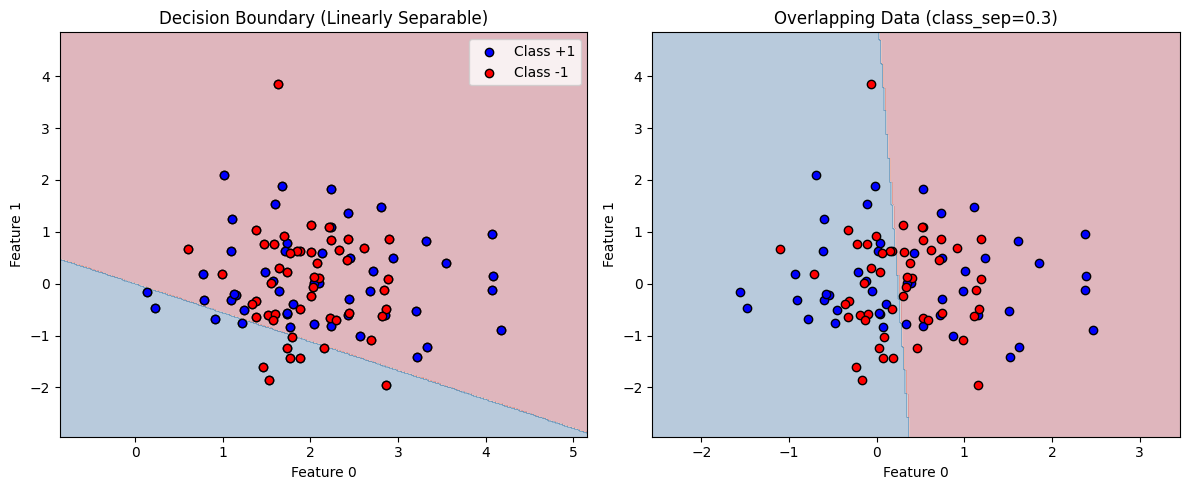

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron


#  Generate a synthetic dataset
# Creating 100 samples with 4 features, 1 cluster per class, and linearly separable (class_sep=2)
X, y = make_classification(
    n_samples=100,
    n_features=4,
    n_informative=2, # Using 2 informative features to make 2D plotting easier
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=42
)

#  Convert labels from {0, 1} to {-1, +1}
y = np.where(y == 0, -1, 1)

# Visualize the data (using the first two features for a 2D scatterplot)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class +1', edgecolor='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', edgecolor='k')
plt.title("Linearly Separable Data (class_sep=2)")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend()

#  Train the Perceptron
clf = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
clf.fit(X, y)

# Print learned weights and bias
print("--- Linearly Separable Perceptron ---")
print(f"Learned Weight Vector (w): {clf.coef_}")
print(f"Learned Bias (b): {clf.intercept_}")

#  Visualize Decision Boundary
# Create a mesh grid over the first two features
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Since the model expects 4 features, we pad the grid with zeros for feature 2 and 3
grid_points = np.c_[xx.ravel(), yy.ravel(), np.zeros_like(xx.ravel()), np.zeros_like(xx.ravel())]
Z = clf.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', edgecolor='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', edgecolor='k')
plt.title("Decision Boundary (Linearly Separable)")


# Select a new test point
test_point = np.array([[1.5, -1.0, 0.5, 0.2]])

# Model prediction
predicted_class = clf.predict(test_point)[0]

# Manual calculation: (w * x) + b
weights = clf.coef_[0]
bias = clf.intercept_[0]
dot_product = np.dot(weights, test_point[0])
manual_calculation = dot_product + bias
manual_sign = np.sign(manual_calculation)

print("\n--- Evaluation on Test Point ---")
print(f"Test Point: {test_point[0]}")
print(f"Model Prediction: {predicted_class}")
print(f"Manual Calculation Output: {manual_calculation:.4f}")
print(f"Sign of Manual Calculation: {manual_sign}")



# Generate overlapping dataset (class_sep=0.3)
X_overlap, y_overlap = make_classification(
    n_samples=100,
    n_features=4,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.3,
    random_state=42
)
y_overlap = np.where(y_overlap == 0, -1, 1)

# Train Perceptron on overlapping data
clf_overlap = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
clf_overlap.fit(X_overlap, y_overlap)

# Visualize overlapping data and boundary
plt.subplot(1, 2, 2)
x_min_ov, x_max_ov = X_overlap[:, 0].min() - 1, X_overlap[:, 0].max() + 1
y_min_ov, y_max_ov = X_overlap[:, 1].min() - 1, X_overlap[:, 1].max() + 1
xx_ov, yy_ov = np.meshgrid(np.arange(x_min_ov, x_max_ov, 0.02),
                           np.arange(y_min_ov, y_max_ov, 0.02))

grid_points_ov = np.c_[xx_ov.ravel(), yy_ov.ravel(), np.zeros_like(xx_ov.ravel()), np.zeros_like(xx_ov.ravel())]
Z_ov = clf_overlap.predict(grid_points_ov)
Z_ov = Z_ov.reshape(xx_ov.shape)

plt.contourf(xx_ov, yy_ov, Z_ov, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X_overlap[y_overlap == 1, 0], X_overlap[y_overlap == 1, 1], color='blue', edgecolor='k')
plt.scatter(X_overlap[y_overlap == -1, 0], X_overlap[y_overlap == -1, 1], color='red', edgecolor='k')
plt.title("Overlapping Data (class_sep=0.3)")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

plt.tight_layout()
plt.show()